In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [23]:
#creating own dataset
from sklearn.datasets import make_classification
X,y=make_classification(n_samples=1000,n_features=2,n_redundant=0,n_classes=2,n_clusters_per_class=2)


In [15]:
pd.DataFrame(X)

,0,1
0,1.728019,1.464148
1,1.294617,1.123873
2,1.047311,0.880289
3,0.960606,-1.041643
4,0.876096,0.943623
...,...,...
995,0.290835,-0.119402
996,0.855988,0.845830
997,2.188801,-2.375895
998,1.517117,1.235879


In [24]:
y

array([0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0,

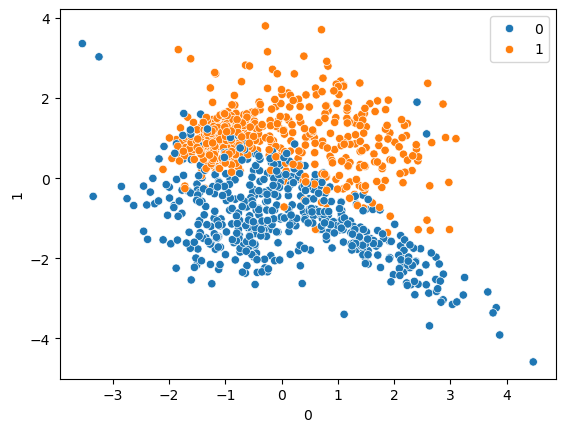

In [25]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [27]:
from sklearn.svm import SVC
svc=SVC(kernel='linear')
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)

In [28]:
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[107  21]
 [ 11 111]]
              precision    recall  f1-score   support

           0       0.91      0.84      0.87       128
           1       0.84      0.91      0.87       122

    accuracy                           0.87       250
   macro avg       0.87      0.87      0.87       250
weighted avg       0.87      0.87      0.87       250



In [29]:
rbf=SVC(kernel='rbf')
rbf.fit(X_train,y_train)
y_pred1=rbf.predict(X_test)
print(confusion_matrix(y_test,y_pred1))
print(classification_report(y_test,y_pred1))

[[114  14]
 [ 10 112]]
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       128
           1       0.89      0.92      0.90       122

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.90      0.90      0.90       250



In [30]:
poly=SVC(kernel='poly')
poly.fit(X_train,y_train)
y_pred2=poly.predict(X_test)
print(confusion_matrix(y_test,y_pred2))
print(classification_report(y_test,y_pred2))

[[ 97  31]
 [  5 117]]
              precision    recall  f1-score   support

           0       0.95      0.76      0.84       128
           1       0.79      0.96      0.87       122

    accuracy                           0.86       250
   macro avg       0.87      0.86      0.86       250
weighted avg       0.87      0.86      0.85       250



In [31]:
sig=SVC(kernel='sigmoid')
sig.fit(X_train,y_train)
y_pred3=sig.predict(X_test)
print(confusion_matrix(y_test,y_pred3))
print(classification_report(y_test,y_pred3))

[[98 30]
 [27 95]]
              precision    recall  f1-score   support

           0       0.78      0.77      0.77       128
           1       0.76      0.78      0.77       122

    accuracy                           0.77       250
   macro avg       0.77      0.77      0.77       250
weighted avg       0.77      0.77      0.77       250



Hyperparameter tunning


In [37]:
from sklearn.model_selection import GridSearchCV
params={
        'C':[1,10,100,1000],
        'gamma':[1,0.1,0.01,0.001],
        'kernel':['rbf']
    }
grid=GridSearchCV(SVC(),param_grid=params,n_jobs=-1,refit=True,cv=5)

In [38]:
grid.fit(X_train,y_train)
y_pred4=grid.predict(X_test)

In [40]:
grid.best_estimator_

SVC(C=1000, gamma=0.1)

In [39]:
print(confusion_matrix(y_test,y_pred4))
print(classification_report(y_test,y_pred4))

[[114  14]
 [  8 114]]
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       128
           1       0.89      0.93      0.91       122

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250



In [41]:
grid.best_params_

{'C': 1000, 'gamma': 0.1, 'kernel': 'rbf'}